In [10]:
import torchvision
from torchvision import datasets
from torchmetrics import Accuracy
import torch
from tqdm.auto import tqdm
from torch import nn
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import torchmetrics
from rich import print

train_data = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform= torchvision.transforms.ToTensor(),
    target_transform=None
)

test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform= torchvision.transforms.ToTensor(),
    target_transform=None
)

In [4]:
device = 'cuda' if torch.cuda.is_available() else "cpu"


print(device)

cuda

In [13]:
class_names = train_data.classes

In [12]:

BATCH_SIZE: int = 32

train_dataloader = DataLoader(
    dataset=train_data,
    batch_size= BATCH_SIZE,
    shuffle= True,
)

test_dataloader = DataLoader(
    dataset=test_data,
    batch_size=BATCH_SIZE,
    shuffle=False
)

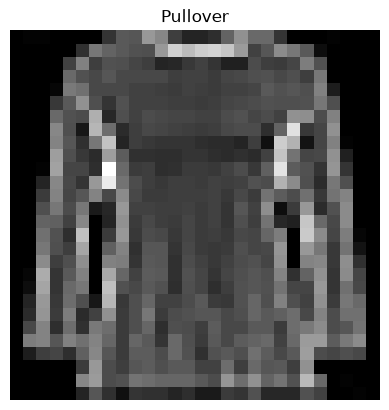

In [16]:
torch.manual_seed(42)

for train_features_batch, train_labels_batch in train_dataloader:
    random_idx = torch.randint(0, len(train_features_batch), size=(1,)).item()
    img, label = train_features_batch[random_idx], train_labels_batch[random_idx]
    plt.imshow(img.squeeze(dim=0), cmap='gray')
    plt.axis(False)
    plt.title(class_names[label])
    break
    

In [6]:
class FashionMNISTModelV0(nn.Module):

    def __init__(self, 
                 input_shape: int,
                 hidden_layer1: int,
                 output_shape: int
                 ):
        super().__init__()

        self.layers = nn.Sequential(
            nn.Flatten(),

            nn.Linear(
                in_features= input_shape, 
                out_features= hidden_layer1,
            ),

            # nn.ReLU(),

            nn.Linear(
                in_features= hidden_layer1,
                out_features= output_shape 
            )
        )

    def forward(self, x: torch.Tensor):
        return self.layers(x)

model_0 = FashionMNISTModelV0(
    input_shape= train_data.data.shape[1] * train_data.data.shape[2],
    hidden_layer1= 10,
    output_shape= len(train_data.classes),
).to(device)



In [48]:
model_0

FashionMNSITModelV0(
  (layers): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=10, bias=True)
    (2): Linear(in_features=10, out_features=10, bias=True)
  )
)

In [ ]:


LEARING_RATE = 0.01
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(
    params=model_0.parameters(),
    lr= LEARING_RATE
)

In [ ]:
acc_fn = Accuracy(
    task= "multiclass",
    num_classes=len(train_data.classes)
).to(device)

In [ ]:

torch.manual_seed(42)

epochs = 3

for epoch in tqdm(range(epochs)):

    train_loss, train_acc = 0.0, 0.0
    for batch, (X, y) in enumerate(train_dataloader):
        model_0.train()

        X = X.to(device)
        y = y.to(device)

        y_logits = model_0(X)

        train_acc += acc_fn(y_logits.argmax(dim=1), y).item()

        loss = loss_fn(y_logits, y)


        optimizer.zero_grad()

        train_loss += loss.item()

        loss.backward()

        optimizer.step()

        if batch % 400 == 0:
            print(f"Batch no. {batch} , looked at {batch * len(X)}/{len(train_data)}")


    # Taking the average
    train_loss /= len(train_dataloader)
    train_acc /= len(train_dataloader)


    test_loss, test_acc = 0.0, 0.0

    model_0.eval()

    with torch.inference_mode():

        for X_test , y_test in test_dataloader:


            X_test = X_test.to(device)
            y_test = y_test.to(device)

            test_logits = model_0(X_test)

            test_loss += loss_fn(test_logits, y_test).item()

            test_acc += acc_fn(test_logits.argmax(dim=1), y_test).item()


        test_loss /= len(test_dataloader)

        test_acc /= len(test_dataloader)


    print(f"Train Loss: {train_loss:.4f} | Test Loss: {test_loss:.4f}")
    print(f"Train Accuracy: {train_acc:.2%} | Test Accuracy: {test_acc:.2%}")
    print("[green]#[/green]" * 20)



  0%|          | 0/3 [00:00<?, ?it/s]

Batch no. 0 , looked at 0/60000

Batch no. 400 , looked at 12800/60000

Batch no. 800 , looked at 25600/60000

Batch no. 1200 , looked at 38400/60000

...

Batch no. 1600 , looked at 51200/60000

Train Loss: 0.4524 | Test Loss: 0.4785

Train Accuracy: 84.30% | Test Accuracy: 83.18%

####################

100%|██████████| 3/3 [01:48<00:00, 36.04s/it]


In [ ]:

def eval_model(
        model: nn.Module,
        loss_fn: nn.Module,
        accuracy_fn: torchmetrics.Metric,
        data_loader: torch.utils.data.DataLoader,
        device= "cpu"
):
    loss, acc = 0.0,0.0

    model.to(device)

    model.eval()

    with torch.inference_mode():

        for X, y in tqdm(data_loader):

            X = X.to(device)
            y = y.to(device)

            y_logits = model(X)

            loss += loss_fn(y_logits, y).item()

            acc += accuracy_fn(y_logits.argmax(dim=1), y).item()

        loss /= len(data_loader)
        acc /= len(data_loader)

    print(f"Test Loss: {loss: .2f} | Test Accuracy: {acc: .2%}")

    return {
        "test_loss": loss,
        "test_accuracy": acc
    }





In [ ]:
torch.optim.Optimizer

In [18]:

def train_step(
        model: nn.Module,
        loss_fn: nn.Module,
        optimizer: torch.optim.Optimizer,
        accuracy_fn: torchmetrics.Metric,
        data_loader: torch.utils.data.DataLoader,
        device= "cpu"
):
    loss = torch.Tensor((0.0,)).to(device)

    model.to(device)

    model.train()

    accuracy_fn.reset()

    for X, y in tqdm(data_loader):

        X = X.to(device)
        y = y.to(device)

        y_logits = model(X)

        loss_batch = loss_fn(y_logits, y)

        optimizer.zero_grad()

        loss_batch.backward()

        loss += loss_batch.detach()

        accuracy_fn.update(
            y_logits.argmax(dim=1),
            y
        )

        # acc += accuracy_fn(y_logits.argmax(dim=1), y).item()

        optimizer.step()

    loss = (loss / len(data_loader)).item()

    acc = accuracy_fn.compute().item()

    print(f"Train Loss: {loss: .2f} | Train Accuracy: {acc: .2%}")

    return {
        "train_loss": loss,
        "train_accuracy": acc
    }


In [19]:
def test_step(
    model: nn.Module,
    loss_fn: nn.Module,
    accuracy_fn: torchmetrics.Metric,
    data_loader: torch.utils.data.DataLoader,
    device= "cpu"
):
    loss = torch.Tensor((0.0,)).to(device)

    model.to(device)

    model.eval()

    accuracy_fn.reset()

    with torch.inference_mode():

        for X, y in tqdm(data_loader):

            X = X.to(device)
            y = y.to(device)

            y_logits = model(X)

            loss += loss_fn(y_logits, y).detach()

            accuracy_fn.update(y_logits.argmax(dim=1), y)

        loss = (loss / len(data_loader)).item()
        acc = accuracy_fn.compute().item()

    print(f"Test Loss: {loss: .2f} | Test Accuracy: {acc: .2%}")



In [ ]:
eval_model

In [72]:
eval_model(
    model= model_0,
    loss_fn=loss_fn,
    accuracy_fn=acc_fn,
    data_loader= test_dataloader,
    device="cuda"
)

100%|██████████| 313/313 [00:03<00:00, 93.72it/s] 


Test Loss:  0.48 | Test Accuracy:  83.18%

In [7]:
class FashionMNISTModelV1(nn.Module):

    def __init__(self,
                 input_shape: int,
                 hidden_layer1: int,
                 output_shape: int):

        super().__init__()

        self.layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(
                in_features= input_shape,
                out_features= hidden_layer1
            ),
            nn.ReLU(),
            nn.Linear(
                in_features=hidden_layer1,
                out_features=output_shape
            ),
            nn.ReLU()
        )


    def forward(self, x: torch.Tensor):
        return self.layers(x)

In [8]:
model_1 = FashionMNISTModelV1(
    input_shape= train_data.data.shape[1] * train_data.data.shape[2],
    hidden_layer1= 10,
    output_shape= len(train_data.classes),
).to(device)

In [9]:
LEARING_RATE = 0.1
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(
    params=model_1.parameters(),
    lr= LEARING_RATE
)

In [ ]:
acc_fn = Accuracy(
    task= "multiclass",
    num_classes=len(train_data.classes)
).to(device)

In [69]:

EPOCHS = 3

for epoch in tqdm(range(EPOCHS)):
    train_step(
        model=model_1,
        loss_fn=loss_fn,
        optimizer=optimizer,
        accuracy_fn=acc_fn,
        data_loader=train_dataloader,
        device=device
    )

    test_step(
        model=model_1,
        loss_fn=loss_fn,
        accuracy_fn=acc_fn,
        data_loader=test_dataloader,
        device=device
    )


100%|██████████| 235/235 [00:09<00:00, 23.98it/s]


Train Loss:  1.23 | Train Accuracy:  63.53%

100%|██████████| 40/40 [00:01<00:00, 29.94it/s]


Test Loss:  0.98 | Test Accuracy:  70.05%

100%|██████████| 235/235 [00:08<00:00, 26.44it/s]


...

100%|██████████| 235/235 [00:08<00:00, 26.32it/s]


Train Loss:  0.86 | Train Accuracy:  72.36%

100%|██████████| 40/40 [00:01<00:00, 37.00it/s]


Test Loss:  0.85 | Test Accuracy:  72.65%

100%|██████████| 3/3 [00:31<00:00, 10.44s/it]


In [21]:
!nvidia-smi

Wed Sep 30 00:10:58 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 615.71.08              KMD Version: 616.92        CUDA UMD Version: 13.4     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3050 ...    On  |   00000000:01:00.0 Off |                  N/A |
| N/A   42C    P8              3W /   95W |     133MiB /   6144MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [7]:
test_image = torch.randn(size=(32,3, 64, 64))
conv_model = nn.Conv2d(
    in_channels=3,
    out_channels=10,
    kernel_size=3,
    padding=0,
    stride=1
)

In [8]:
conv_model(test_image)

tensor([[[[ 4.4049e-01,  5.0173e-01,  5.0944e-01,  ..., -1.1179e-01,
            1.2756e-01, -5.7251e-01],
          [ 5.9133e-01, -8.6406e-01,  3.4698e-01,  ...,  9.6804e-01,
           -4.9961e-01,  1.0262e+00],
          [-2.4145e-01, -4.7024e-02,  6.2166e-01,  ..., -2.0256e-01,
           -4.7248e-01,  6.5543e-01],
          ...,
          [ 8.4685e-02,  4.9555e-01,  1.1499e-01,  ...,  2.6158e-02,
            7.1445e-01,  1.9746e-01],
          [ 1.3581e+00, -5.9261e-01, -5.7118e-01,  ..., -2.4530e-01,
           -3.8858e-01,  2.0289e-01],
          [-7.1790e-01,  1.5215e-01, -3.9305e-01,  ..., -5.0526e-01,
            2.5250e-01,  1.7872e-01]],

         [[ 1.8109e-01, -9.3829e-01,  2.0712e-01,  ..., -3.8735e-01,
            3.2904e-01,  6.8252e-01],
          [-3.9721e-01,  8.0270e-01, -4.5923e-01,  ..., -9.9504e-01,
            1.1982e+00,  1.6473e-01],
          [ 2.7811e-01,  2.2750e-01, -2.8746e-01,  ...,  1.3091e+00,
           -2.1823e-01,  1.1500e-01],
          ...,
     

In [14]:

class FashionMNISTModelV2(nn.Module):

    def __init__(self, 
                 input_shape: int,
                 hidden_layer:int, 
                 output_shape: int):

        super().__init__()

        self.conv1 = nn.Sequential(
            nn.Conv2d(
                in_channels= input_shape,
                out_channels= hidden_layer,
                kernel_size=2,
                stride=1,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )

        self.conv2 = nn.Sequential(
            nn.Conv2d(
                in_channels= hidden_layer,
                out_channels= hidden_layer,
                kernel_size=2,
                stride=1,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )

        self.classifer = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=hidden_layer * 7 * 7, out_features=output_shape)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.classifer(x)

        return x

model_2 = FashionMNISTModelV2(
    input_shape= 1, # number of colors
    hidden_layer= 10,
    output_shape= len(train_data.classes),
).to(device)


In [15]:

LEARING_RATE = 0.1
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(
    params=model_2.parameters(),
    lr= LEARING_RATE
)

In [16]:

acc_fn = Accuracy(
    task= "multiclass",
    num_classes=len(train_data.classes)
).to(device)

In [20]:

EPOCHS = 3

for epoch in tqdm(range(EPOCHS)):

    train_step(
        model = model_2,
        loss_fn = loss_fn,
        optimizer = optimizer,
        accuracy_fn = acc_fn,
        data_loader = train_dataloader,
        device = 'cpu'
    )

    test_step(
        model = model_2,
        loss_fn = loss_fn,
        accuracy_fn = acc_fn,
        data_loader = train_dataloader,
        device = 'cpu'
    )

  0%|          | 0/3 [00:00<?, ?it/s]

100%|██████████| 1875/1875 [00:15<00:00, 120.81it/s]


Train Loss:  0.59 | Train Accuracy:  78.94%

100%|██████████| 1875/1875 [00:07<00:00, 258.72it/s]


Test Loss:  0.39 | Test Accuracy:  85.92%

...

100%|██████████| 1875/1875 [00:11<00:00, 160.19it/s]


Train Loss:  0.35 | Train Accuracy:  87.41%

100%|██████████| 1875/1875 [00:07<00:00, 237.51it/s]


Test Loss:  0.32 | Test Accuracy:  88.69%

100%|██████████| 3/3 [01:05<00:00, 21.85s/it]


In [23]:
from pathlib import Path
folder_path: Path = Path() / 'exercises' / 'models'
folder_path.mkdir(parents= True, exist_ok= True)
name: str = 'fashion_mnist_model.pth'
file_path: Path = folder_path / name

torch.save(obj=model_2.state_dict(), f= file_path)